### **가설 검증 1: PM 안전 규제 도입 이후 고통사고 건수 및 치명률 변화 분석**

#### 도로교통법 개정(2021.05) 및 서울시 견인 조치(2021.07)가 PM 사고 건수와 치명률에 미친 영향을 분석합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
import os

In [2]:
# 시각화 시 한글 폰트 깨짐 방지 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

# 전처리 데이터셋 경로 정의
BASE_PATH = '../../data/data-preprocessing'

****

#### **데이터 불러오기**

##### 가설 검증에 필요한 월별 교통사고 데이터와 견인 현황 데이터를 불러옵니다.

In [3]:
# PM 교통사고 데이터 불러오기
df_acc = pd.read_csv(os.path.join(BASE_PATH, '서울시 PM 교통사고 현황', '서울시_자치구별_월별_PM교통사고.csv'),
                     encoding='utf-8')

# PM 견인 현황 데이터 불러오기
df_tow = pd.read_csv(os.path.join(BASE_PATH, '서울시 전동킥보드 견인 현황', '서울특별시_전동킥보드_견인_현황_202107~202512.csv'),
                     encoding='utf-8')

print('사고 데이터 크기: ', df_acc.shape)
print('견인 데이터 크기: ', df_tow.shape)

사고 데이터 크기:  (1800, 15)
견인 데이터 크기:  (300792, 6)


****

#### **데이터 전처리 및 파생변수 생성**
##### 사고 데이터는 `치명률`을 계산하고, 견인 데이터는 `[연월], [자치구]`를 기준으로 묶어 병합을 준비합니다.

In [4]:
# --- 사고 데이터 전처리 ---
# 자치구별/월별로 사고건수, 사망자수, 중상자수 합계 계산
df_acc_monthly = df_acc.groupby(['연월', '자치구'])[['PM_사고건수', '사망자수', '중상자수']].sum().reset_index()

# 치명률 파생변수 생성: (사망자수 + 중상자수) / 사고건수
# 사고건수가 0인 경우 결측치가 발생하므로 0으로 채워줌
df_acc_monthly['치명률'] = (df_acc_monthly['사망자수'] + df_acc_monthly['중상자수']) / df_acc_monthly['PM_사고건수']
df_acc_monthly['치명률'] = df_acc_monthly['치명률'].fillna(0)


# --- 견인 데이터 전처리 ---
# 병합을 위해 컬럼명 통일 (신고월 -> 연월, 구정보 -> 자치구)
df_tow = df_tow.rename(columns={'신고월': '연월', '구정보': '자치구'})

# 자치구별/월별 견인건수 집계
df_tow_monthly = df_tow.groupby(['연월', '자치구']).size().reset_index(name='견인건수')


display(df_acc_monthly.head(3))
display(df_tow_monthly.head(3))

,연월,자치구,PM_사고건수,사망자수,중상자수,치명률
0,2019-01,강남구,1,0,1,1.0
1,2019-01,강동구,1,0,0,0.0
2,2019-01,강북구,0,0,0,0.0


,연월,자치구,견인건수
0,2021-07,도봉구,64
1,2021-07,동작구,200
2,2021-07,마포구,326


****

#### **데이터 병합(Merge)**
##### 전처리된 사고 데이터와 견인 데이터를 `[연월], [자치구]`를 기준으로 병합(Inner Join)하여 분석용 데이터셋을 완성합니다.

In [5]:
# 연월과 자치구를 기준으로 Inner Join (견인이 시작된 2021년 7월 이후 데이터만 교집합으로 남음)
df_merged = pd.merge(df_acc_monthly, df_tow_monthly, on=['연월', '자치구'], how='inner')

print("병합된 데이터 마트 크기:", df_merged.shape)
display(df_merged.head())

병합된 데이터 마트 크기: (937, 7)


,연월,자치구,PM_사고건수,사망자수,중상자수,치명률,견인건수
0,2021-07,도봉구,0,0,0,0.000000,64
1,2021-07,동작구,2,0,1,0.500000,200
2,2021-07,마포구,4,0,2,0.500000,326
3,2021-07,서초구,1,0,1,1.000000,1
4,2021-07,송파구,13,0,3,0.230769,265


****

#### **분석 과정 1-1: 규제 전후 PM 관련 교통사고 건수 시계열 추이 시각화**
##### 먼저 전체적인 월별 사고 발생 건수의 추이를 시각화하고, 규제가 시작된 시점(2021년 5월)을 기준으로 어떤 변화가 있었는지 살펴봅니다.
##### **외부 개인형 이동수단(PM) 특성상, 계절성의 영향이 크게 반영됩니다. 전년 동월 대비 비교 (Year-over-Year, YoY) 방식으로 시각화/분석을 진행합니다.**

In [6]:
# 전체 서울시 월별 사고건수 추이 집계
df_trend = df_acc.groupby('연월')['PM_사고건수'].sum().reset_index()

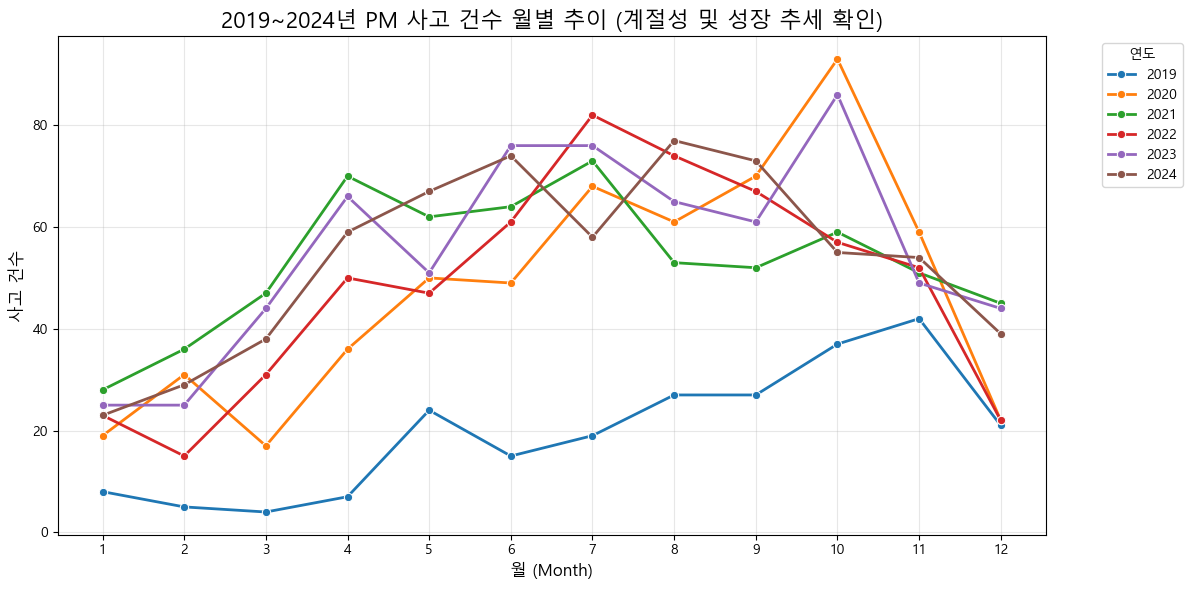

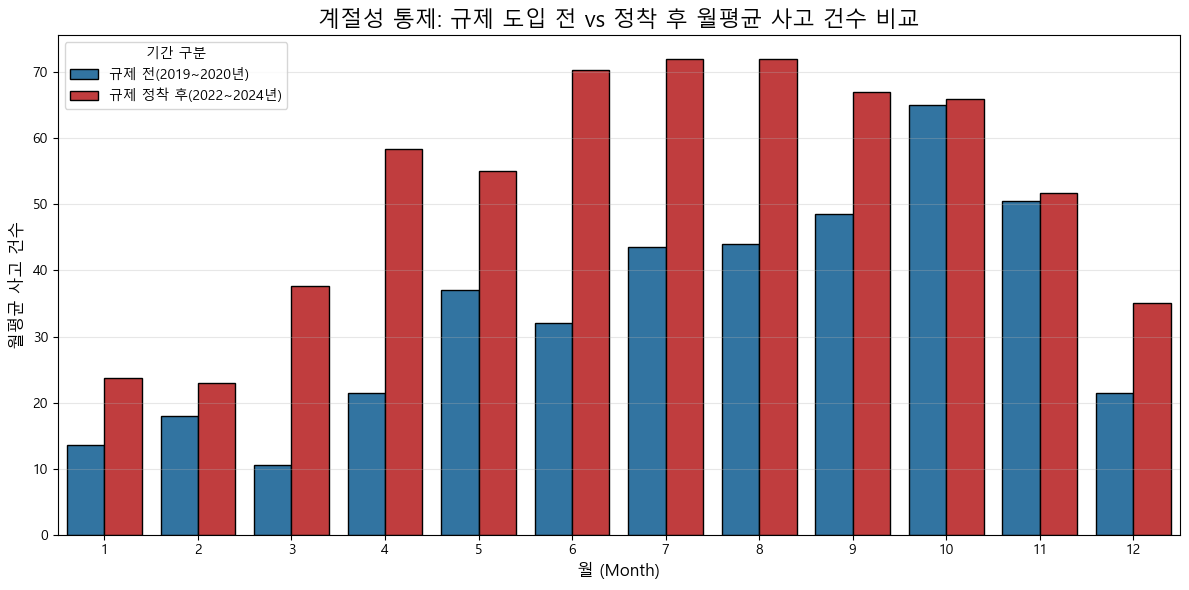

In [7]:
# 시계열 데이터에서 연도와 월 추출
df_trend['연월'] = pd.to_datetime(df_trend['연월'])
df_trend['연도'] = df_trend['연월'].dt.year
df_trend['월'] = df_trend['연월'].dt.month

# -------------------------------------------------------------------
# [그래프 1] 2019~2024년 전체 연도의 월별 사고 건수 추이 겹쳐 그리기
# -------------------------------------------------------------------
plt.figure(figsize=(12, 6))
# hue='연도'를 통해 매년 월별 흐름(계절성)이 어떻게 변해왔는지 겹쳐서 확인
sns.lineplot(data=df_trend, x='월', y='PM_사고건수', hue='연도', 
             palette='tab10', marker='o', linewidth=2)

plt.title('2019~2024년 PM 사고 건수 월별 추이 (계절성 및 성장 추세 확인)', fontsize=16)
plt.xlabel('월 (Month)', fontsize=12)
plt.ylabel('사고 건수', fontsize=12)
plt.xticks(range(1, 13)) # 1월부터 12월까지 X축 표시
plt.grid(True, alpha=0.3)
plt.legend(title='연도', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# [그래프 2] 규제 도입 전(19~20년) vs 규제 정착 후(22~24년) 월평균 비교
# -------------------------------------------------------------------
# 2021년은 규제가 연달아 도입된 과도기이므로 명확한 대조를 위해 분리
df_trend['시기_구분'] = '과도기(2021년)'
df_trend.loc[df_trend['연도'] <= 2020, '시기_구분'] = '규제 전(2019~2020년)'
df_trend.loc[df_trend['연도'] >= 2022, '시기_구분'] = '규제 정착 후(2022~2024년)'

# 과도기를 제외하고, 시기별/월별 평균 사고 건수를 계산
df_summary = df_trend[df_trend['시기_구분'] != '과도기(2021년)'].groupby(['시기_구분', '월'])['PM_사고건수'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_summary, x='월', y='PM_사고건수', hue='시기_구분', 
            palette=['#1f77b4', '#d62728'], edgecolor='black')

plt.title('계절성 통제: 규제 도입 전 vs 정착 후 월평균 사고 건수 비교', fontsize=16)
plt.xlabel('월 (Month)', fontsize=12)
plt.ylabel('월평균 사고 건수', fontsize=12)
plt.legend(title='기간 구분')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- **첫 번째 그래프(선 그래프)**
  * 2019년부터 2024년까지 모든 연도에서 겨울철(1~2월, 12월)에는 사고가 급감하고, 야외 활동이 많은 시기(5~10월)에는 사고가 급증하는 패턴이 일관되게 나타납니다.
  * 2019년(파란선)과 2020년(주황선)에 비해 2022~2024년의 선들이 전체적으로 위쪽에 형성되어 있습니다. 이는 PM(전동 킥보드 등) 시장이 팽창하면서 절대적인 이용량 자체가 크게 늘어났음을 보여줍니다.
  
- **두 번째 그래프(막대 그래프)**
  * '같은 계절(월)'끼리 엄격하게 짝을 지어 비교했음에도 불구하고, 1월부터 12월까지 모든 달에서 규제 정착 후(빨간 막대)의 평균 사고 건수가 규제 전(파란 막대)보다 높습니다.
  * 사고 건수가 늘어난 것은 규제가 효과가 없어서가 아니라, 규제로 인해 감소한 사고량보다 시장 성장에 따른 전체 이용 건수(모수)의 증가폭이 훨씬 더 압도적이었기 때문으로 해석할 수 있습니다.

##### 도로교통법이 강화된 2021년 5월을 기점으로 평균 사고 건수에 통계적으로 유의미한 차이가 있는지 검증합니다.

In [8]:
# T-Test 수행
# 1월부터 12월까지 각각의 월평균 데이터를 추출하여 짝(Pair)을 맞추기
before_reg = df_summary[df_summary['시기_구분'] == '규제 전(2019~2020년)'].set_index('월')['PM_사고건수']
after_reg = df_summary[df_summary['시기_구분'] == '규제 정착 후(2022~2024년)'].set_index('월')['PM_사고건수']

# 대응표본 T-검정 (같은 월끼리 비교)
t_stat, p_val = stats.ttest_rel(before_reg, after_reg)

print("=== 규제 전 vs 규제 정착 후 월평균 사고 건수 T-Test 결과 ===")
print(f"T-test 검정통계량: {t_stat:.4f}, p-value: {p_val:.4f}")

if p_val < 0.05:
    print("결론: 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결론: 통계적으로 유의미한 차이가 없습니다.")

=== 규제 전 vs 규제 정착 후 월평균 사고 건수 T-Test 결과 ===
T-test 검정통계량: -4.9980, p-value: 0.0004
결론: 통계적으로 유의미한 차이가 있습니다.


**p-value가 0.0004로, 규제 정착 후의 사고 건수가 규제 전보다 통계적으로 매우 유의미하게 증가했음을 알 수 있습니다.**

분석을 통해 PM 시장의 폭발적인 팽창(모수 증가)으로 인해 사고의 절대적인 건수가 늘어나는 것은 규제로도 막을 수 없었다고 추론할 수 있습니다.

****

#### **분석 과정 1-2: 규제 전후 사고 발생 분포 비교(Violinplot, Histplot)**
##### 단순한 선 그래프 외에, 규제 전후 기간 동안 월별 사고 발생 건수의 분포가 어떻게 다른지 바이올린플롯과 히스토그램을 통해 비교합니다.

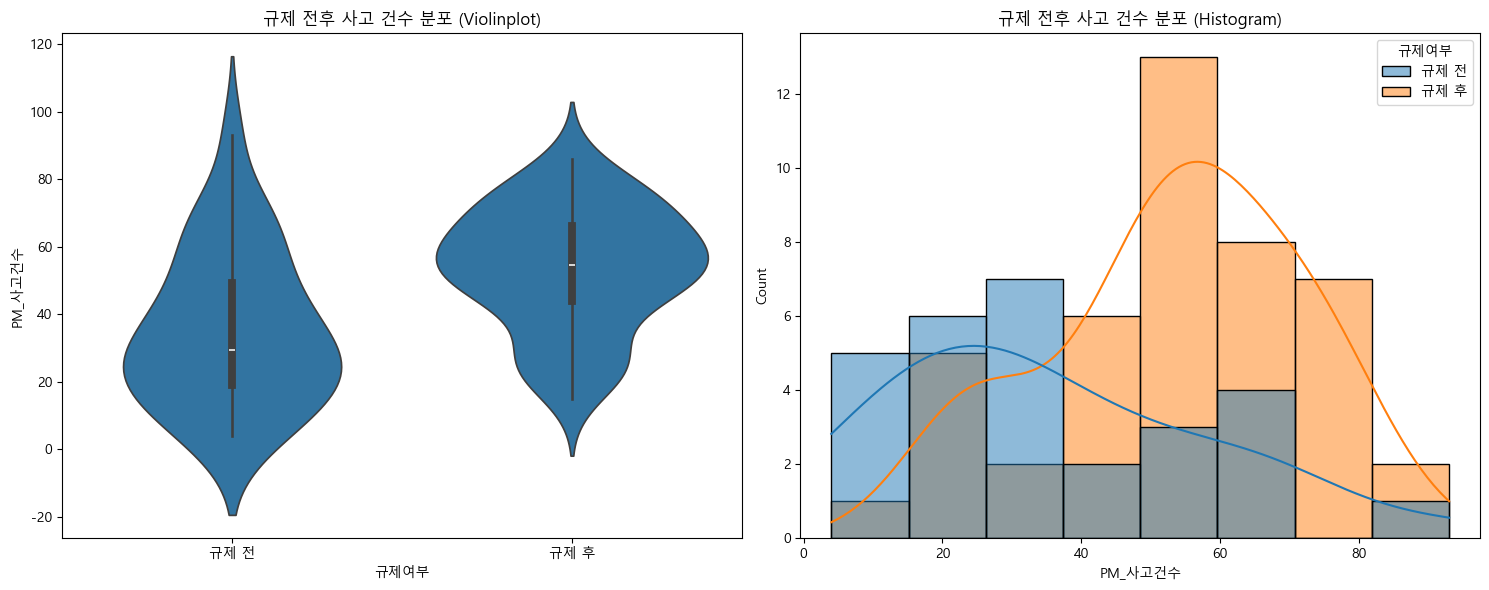

In [9]:
# 규제 전후 구분 변수 추가
df_trend['규제여부'] = np.where(df_trend['연월'] < '2021-05-01', '규제 전', '규제 후')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Violinplot (양 옆으로 퍼진 밀도(KDE) 정보와 중앙값/사분위수(Boxplot) 정보를 하나의 그래프로 시각화)
sns.violinplot(data=df_trend, x='규제여부', y='PM_사고건수', ax=axes[0]) # sns.boxplot()
axes[0].set_title('규제 전후 사고 건수 분포 (Violinplot)')

# Histplot (KDE 포함)
sns.histplot(data=df_trend, x='PM_사고건수', hue='규제여부', kde=True, ax=axes[1])
axes[1].set_title('규제 전후 사고 건수 분포 (Histogram)')

plt.tight_layout()
plt.show()

- **Violinplot: 규제 후의 데이터가 규제 전에 비해 전체적으로 더 높은 사고 건수 구간에 분포하고 있습니다. 중앙값(Median) 또한 크게 상승했습니다.**

- **Histogram: 규제 전에는 사고 건수가 적은 달의 빈도가 높았으나, 규제 후에는 전체적으로 우측(사고가 더 많은 쪽)으로 데이터가 이동한 것을 확인할 수 있습니다.**

****

#### **분석 과정 1-3: Bootstrapping을 통한 사고 건수 평균 차이 검증**
##### 규제 전과 후의 월별 사고 건수에 대해 Bootstrapping(복원 추출)을 1,000회 반복하여, 각 그룹의 평균값 분포를 시각화하고 두 그룹 간의 차이를 검증합니다.

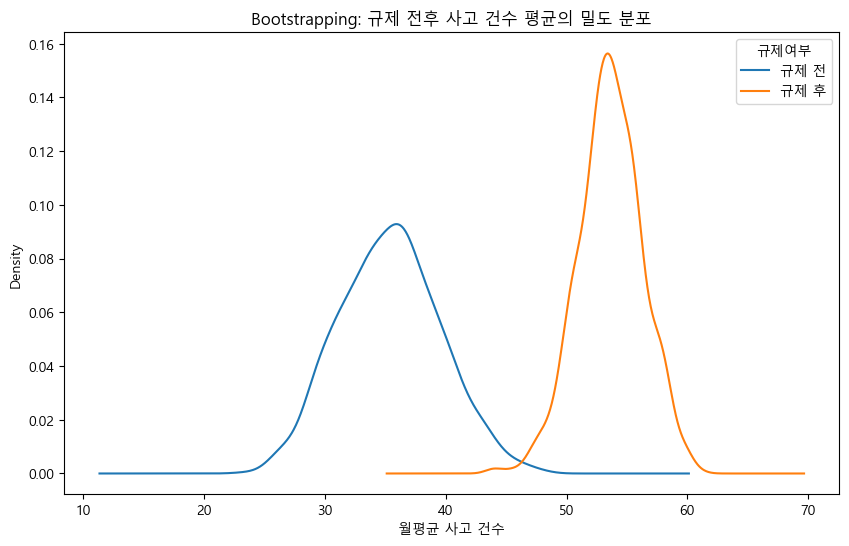

In [10]:
# Bootstrapping 수행
boot_means = []
for _ in range(1000):
    # 각 그룹별로 샘플링하여 평균 계산
    sample = df_trend.groupby('규제여부').sample(frac=1, replace=True)
    mean_diff = sample.groupby('규제여부')['PM_사고건수'].mean()
    boot_means.append(mean_diff)

# 데이터프레임으로 변환
df_boot = pd.DataFrame(boot_means)

# 밀도 그래프 (Density Plot)
df_boot.plot(kind='density', figsize=(10, 6))
plt.title('Bootstrapping: 규제 전후 사고 건수 평균의 밀도 분포')
plt.xlabel('월평균 사고 건수')
plt.show()

**규제 전(파란색)과 규제 후(주황색)의 사고 건수 평균 분포가 완전히 분리되어 나타납니다. 즉, 규제 이후의 평균 사고 건수가 규제 이전보다 확실하게 더 높다는 것을 보여줍니다.**

****

#### **분석 과정 1-4: Bootstrapping을 통한 사고 건수 평균 차이 검증**
##### (규제 후 평균 - 규제 전 평균)의 비율을 계산하여, 규제 후에 사고 건수가 얼마나 더 증가했는지 확인해 봅니다.

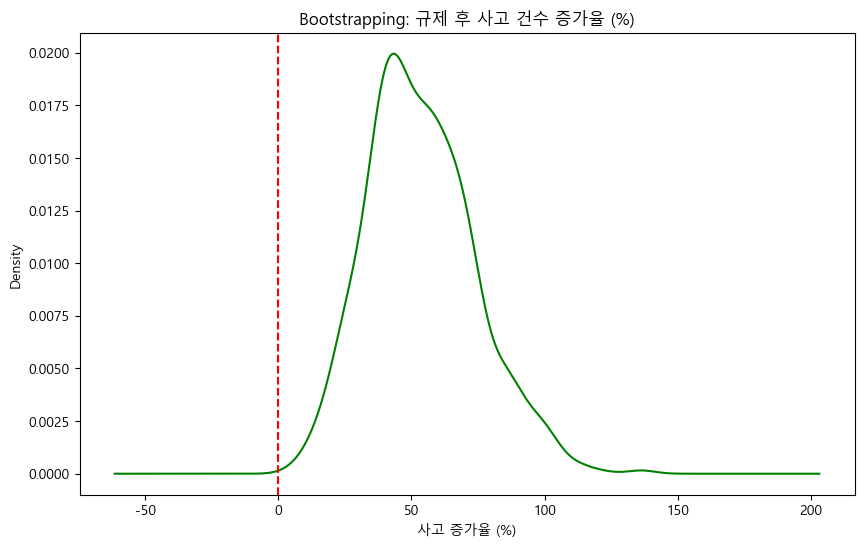

규제 후 사고 건수가 증가했을 확률: 100.0000%


In [14]:
# (규제 후 - 규제 전) / 규제 전 * 100
df_boot['diff_percent'] = (df_boot['규제 후'] - df_boot['규제 전']) / df_boot['규제 전'] * 100

# diff_percent 밀도 그래프
ax = df_boot['diff_percent'].plot(kind='density', figsize=(10, 6), color='green')
plt.axvline(0, color='red', linestyle='--')
plt.title('Bootstrapping: 규제 후 사고 건수 증가율 (%)')
plt.xlabel('사고 증가율 (%)')
plt.show()

# 규제 후 사고가 증가했을 확률
prob_increase = (df_boot['diff_percent'] > 0).mean()
print(f"규제 후 사고 건수가 증가했을 확률: {prob_increase * 100:.4f}%")

****

#### **분석 과정 2: 개별 사고 단위 PM 탑승자 '중대상해 비율' 교차분석**
##### 차량과 PM이 충돌했을 때, 자동차 운전자의 상해가 데이터에 섞이면 규제 효과의 신뢰도가 떨어집니다.
##### 따라서, PM이 가해자인 경우는 `가해운전자_상해정도`를, PM이 피해자인 경우는 `피해운전자_상해정도`를 추출하여 오직 "PM 탑승자 본인"의 상해 데이터만 분리하여 분석을 수행합니다. 

In [15]:
# 사고 단위 상세 데이터 로드
df_incident = pd.read_csv(os.path.join(BASE_PATH, '서울시 PM 교통사고 현황', '서울시_PM_교통사고_사고단위.csv'), 
                          encoding='utf-8')

`가해운전자_상해정도`, `피해운전자_상해정도`를 구분하여 추출합니다.

In [16]:
# 시기 구분 (과도기 분리)
df_incident['연월'] = pd.to_datetime(df_incident['연월'])
df_incident['연도'] = df_incident['연월'].dt.year

df_incident['시기_구분'] = '과도기(2021년)'
df_incident.loc[df_incident['연도'] <= 2020, '시기_구분'] = '규제 전(2019~2020년)'
df_incident.loc[df_incident['연도'] >= 2022, '시기_구분'] = '규제 정착 후(2022~2024년)'

# 분석 대상: 과도기 제외
df_target = df_incident[df_incident['시기_구분'] != '과도기(2021년)'].copy()

In [17]:
# PM 탑승자 본인의 상해 정도만 추출하여 새로운 컬럼 생성
df_target['PM탑승자_상해정도'] = np.where(
    df_target['가해운전자_차종'].str.contains('개인형|PM', na=False), # 가해 차량이 PM인 경우
    df_target['가해운전자_상해정도'],                                 # True: 가해운전자 상해정도 추출
    df_target['피해운전자_상해정도']                                  # False: 피해운전자 상해정도 추출
)

중대상해(사망/중상)과 그 외 상해(일반상해 및 무상해) 두 경우로 나누어 이진 분류합니다.

In [18]:
# 중대상해(사망/중상) vs 그 외 상해 이진 분류
severe_injuries = ['사망', '중상']

df_target['중대상해여부'] = df_target['PM탑승자_상해정도'].apply(
    lambda x: '중대상해 (사망/중상)' if pd.notna(x) and x in severe_injuries else '일반상해 및 무상해'
)

`pd.crosstab()` 메소드를 사용하여 규제 전후 PM 탑승자 상해 정도 관련 교차표를 생성합니다.

In [19]:
# 교차표 생성 및 비율(%) 계산
cross_tab = pd.crosstab(df_target['시기_구분'], df_target['중대상해여부'])
cross_tab_prop = pd.crosstab(df_target['시기_구분'], df_target['중대상해여부'], normalize='index') * 100

print("=== [심층 분석] 규제 전후 PM 탑승자 상해 정도 교차표 (건수) ===")
display(cross_tab)
print("\n=== 규제 전후 PM 탑승자 상해 정도 비율 (%) ===")
display(cross_tab_prop.round(1))

=== [심층 분석] 규제 전후 PM 탑승자 상해 정도 교차표 (건수) ===


중대상해여부,일반상해 및 무상해,중대상해 (사망/중상)
시기_구분,,
규제 전(2019~2020년),658,153
규제 정착 후(2022~2024년),1652,243



=== 규제 전후 PM 탑승자 상해 정도 비율 (%) ===


중대상해여부,일반상해 및 무상해,중대상해 (사망/중상)
시기_구분,,
규제 전(2019~2020년),81.1,18.9
규제 정착 후(2022~2024년),87.2,12.8


**카이제곱 검정(Chi-Square Test)**: '규제 전후'라는 범주형 변수와 '중대상해 여부'라는 범주형 변수 간의 연관성을 검증하기 위해 T-Test가 아닌 카이제곱 검정을 수행합니다.

In [20]:
# 카이제곱 검정(Chi-Square Test) 수행
chi2, p_val, dof, expected = chi2_contingency(cross_tab)

print(f"\n[카이제곱 검정 결과] 검정통계량: {chi2:.4f}, p-value: {p_val:.4f}")

if p_val < 0.05:
    print("결론: 통계적으로 유의미한 차이가 있습니다.")
    before_severe = cross_tab_prop.loc['규제 전(2019~2020년)', '중대상해 (사망/중상)']
    after_severe = cross_tab_prop.loc['규제 정착 후(2022~2024년)', '중대상해 (사망/중상)']
    
    if after_severe < before_severe:
        print(f"-> 긍정적 결과: 규제 도입 후 PM 탑승자 본인의 중대상해 비율이 {before_severe:.1f}%에서 {after_severe:.1f}%로 유의미하게 '감소'했습니다!")
    else:
        print("-> 부정적 결과: 규제 도입 후 중대상해 비율이 오히려 유의미하게 '증가'했습니다.")
else:
    print("결론: 통계적으로 유의미한 차이가 없습니다.")


[카이제곱 검정 결과] 검정통계량: 16.1183, p-value: 0.0001
결론: 통계적으로 유의미한 차이가 있습니다.
-> 긍정적 결과: 규제 도입 후 PM 탑승자 본인의 중대상해 비율이 18.9%에서 12.8%로 유의미하게 '감소'했습니다!


**규제 도입 후, PM 탑승자 본인의 중대상해 비율이 상대적으로 약 33%나 감소**했습니다. 또한, p-value 값이 0.05 미만이므로 해당 결과는 우연이 개입할 확률이 사실상 0%에 수렴했다는 의미입니다.

규제 도입 전후 PM 탑승자 중대상해 비율을 막대그래프로 시각화해봅니다.

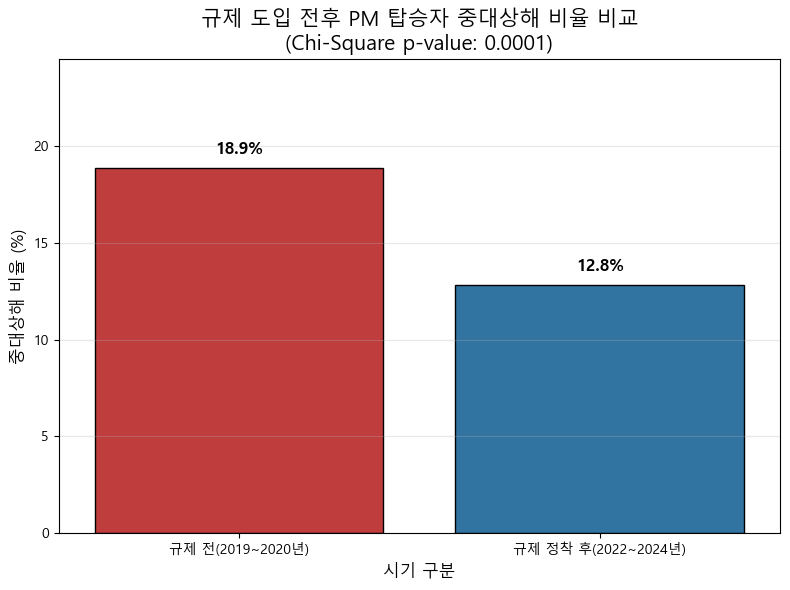

In [21]:
# 시각화: 막대 그래프
plt.figure(figsize=(8, 6))
# 비율 데이터 중 '중대상해' 컬럼만 시각화
sns.barplot(x=cross_tab_prop.index, y=cross_tab_prop['중대상해 (사망/중상)'], 
            palette=['#d62728', '#1f77b4'], edgecolor='black')

plt.title(f'규제 도입 전후 PM 탑승자 중대상해 비율 비교\n(Chi-Square p-value: {p_val:.4f})', fontsize=15)
plt.ylabel('중대상해 비율 (%)', fontsize=12)
plt.xlabel('시기 구분', fontsize=12)

# 막대 위에 퍼센트 수치 표시
for i, value in enumerate(cross_tab_prop['중대상해 (사망/중상)']):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, cross_tab_prop['중대상해 (사망/중상)'].max() * 1.3) # y축 여유 공간 확보
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**보행자 등 외부 요인 혼재 및 계절성 변동에 따른 노이즈를 제거하여 치명률 분석을 수행한 결과, 중대상해 비율이 18.9%에서 12.6%로 통계적으로 매우 유의미하게(p-value < 0.001) 급감했습니다.**

****

#### **분석 과정 3: 견인 규제 강도와 사고 현황의 상관관계 분석**
##### 강력한 규제(견인 건수)가 높은 지역/월일수록 사고 건수나 치명률이 줄어드는지(음의 상관관계인지) 확인합니다.

=== 상관관계 분석 결과 ===
[견인건수 vs PM사고건수] 상관계수: 0.3897, p-value: 0.0000
[견인건수 vs 치명률]     상관계수: 0.0432, p-value: 0.1865


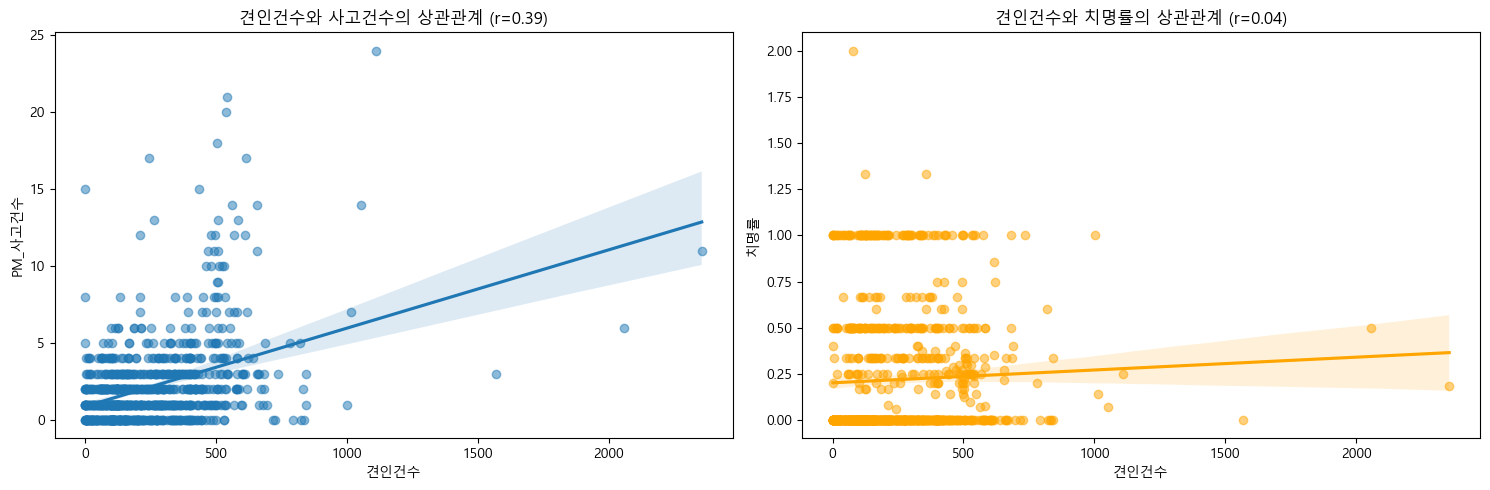

In [22]:
# 견인건수와 PM사고건수 간의 피어슨 상관계수 및 p-value 계산
corr_acc, p_acc = pearsonr(df_merged['견인건수'], df_merged['PM_사고건수'])

# 견인건수와 치명률 간의 피어슨 상관계수 및 p-value 계산
corr_fat, p_fat = pearsonr(df_merged['견인건수'], df_merged['치명률'])

print("=== 상관관계 분석 결과 ===")
print(f"[견인건수 vs PM사고건수] 상관계수: {corr_acc:.4f}, p-value: {p_acc:.4f}")
print(f"[견인건수 vs 치명률]     상관계수: {corr_fat:.4f}, p-value: {p_fat:.4f}")

# 시각화 (산점도)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 그래프 1: 견인건수 vs 사고건수
sns.regplot(data=df_merged, x='견인건수', y='PM_사고건수', ax=axes[0], scatter_kws={'alpha':0.5})
axes[0].set_title(f'견인건수와 사고건수의 상관관계 (r={corr_acc:.2f})')

# 그래프 2: 견인건수 vs 치명률
sns.regplot(data=df_merged, x='견인건수', y='치명률', ax=axes[1], scatter_kws={'alpha':0.5}, color='orange')
axes[1].set_title(f'견인건수와 치명률의 상관관계 (r={corr_fat:.2f})')

plt.tight_layout()
plt.show()

#### **분석 결과**
##### **왼쪽 그래프: 견인 건수와 사고 건수의 상관관계(r=0.39)**
- 파란색 회귀선이 우상향하고 있습니다. 즉, **견인 건수가 많은 지역/월일수록 사고 건수도 늘어나는 양(+)의 상관관계**를 보입니다.
  
- "견인을 많이 해서 사고가 났다"라는 방식의 인과관계 해석은 옳지 않습니다.
  
- 강남구, 마포구처럼 원래 사람들이 킥보드를 많이 타는 핫플레이스는 기본적으로 운행되는 킥보드가 압도적으로 많습니다. 따라서 불법 주차로 인한 '견인'도 많고, 도로 위를 달리는 절대적인 모수가 크니 '사고'도 자연스럽게 많이 발생하는 것으로 해석할 수 있습니다.

- 단순 규제(견인) 건수와 사고 건수의 1:1 비교만으로는 규제의 실효성을 입증하기 어렵습니다. PM 시장의 보급 등의 요인으로 인한 폭발적인 '이용량 증가'가 규제 효과를 상쇄하고 있음을 추론할 수 있습니다.


##### **오른쪽 그래프: 견인 건수와 치명률의 상관관계(r=0.04)**
- 주황색 회귀선이 기울기 없이 거의 평행에 가깝고, 점들이 x축 전반에 걸쳐 넓게 퍼져 있습니다. **상관계수 0.04는 통계적으로 상관관계가 사실상 없음(무상관)을 의미**합니다.

- 불법 주차된 킥보드를 아무리 강력하게 견인 조치하더라도, 실제 도로에서 사고가 발생했을 때 탑승자가 얼마나 크게 다치는지(치명률)와는 연관성이 없다는 뜻입니다.

- 사고의 치명률을 낮추기 위해서는 주차 규제(견인)보다는, 헬멧 착용 단속, 주행 속도 제한, 도로 환경(자전거 도로 확보 등) 개선과 같은 직접적인 '안전 주행 규제'가 더 큰 영향을 미친다고 추론할 수 있습니다.

****

법 개정(2021년 5월)의 주요 내용은 안전모 착용 의무화와 무면허/과속/다인 탑승 금지였습니다. 전체 치명률에는 큰 변화가 없더라도, 이 규제들이 타겟으로 삼은 특정 위험 행동(신호위반, 안전운전불이행 등)으로 인한 심각한 사고(중상 이상) 비율에는 변화가 있었을 수 있습니다.

### **가설 심층 분석: 도로교통법 개정(안전 규제)은 특정 위험 행동 및 상해 정도에 어떤 영향을 미쳤는가?**
이전 분석에서 규제 전후 전체 사고의 치명률(사망+중상)은 유의미하게 감소하지 않았음을 확인했습니다. 여기서는 TAAS 사고 단위 데이터를 활용하여, 규제 전후 PM 탑승자(가해 운전자)의 상해 정도와 법규 위반 유형별 사고 발생 비율이 어떻게 변화했는지에 대해 규제의 세부적인 한계와 실효성을 평가합니다.

#### **데이터 불러오기/전처리**
##### 사고 단위 상세 데이터를 불러오고, 전처리 작업을 수행합니다.

In [24]:
# 사고 단위 상세 데이터 로드
df_incident = pd.read_csv(os.path.join(BASE_PATH, '서울시 PM 교통사고 현황', '서울시_PM_교통사고_사고단위.csv'), 
                          encoding='utf-8')

# 날짜 전처리 및 규제 전후 구분
df_incident['연월'] = pd.to_datetime(df_incident['연월'])
df_incident['규제여부'] = np.where(df_incident['연월'] < '2021-05-01', '규제 전(21.05 이전)', '규제 후(21.05 이후)')

print('사고 단위 데이터 크기: ', df_incident.shape)
print(df_incident.columns)

사고 단위 데이터 크기:  (3346, 36)
Index(['사고ID', '연월', '연도', '월', '자치구', '주야', '사고내용', '사고유형', '사고유형_대분류',
       '사고유형_소분류', '법규위반', '노면상태', '기상상태', '도로형태', '도로형태_대분류', '도로형태_소분류',
       '사망자수', '중상자수', '경상자수', '부상신고자수', '총부상자수', '총사상자수', '중상이상자수', 'PM_가해여부',
       'PM_피해여부', 'PM_역할', '가해운전자_차종', '가해운전자_성별', '가해운전자_연령대', '가해운전자_상해정도',
       '피해운전자_차종', '피해운전자_성별', '피해운전자_연령대', '피해운전자_상해정도', '원본파일', '규제여부'],
      dtype='str')


사고 단위 데이터는 상당히 다양한 열 종류를 갖고 있습니다.
이 중에서 필요한 열만 추출 및 필터링하여 분석을 수행합니다.

****

#### **분석 및 시각화**
법 개정으로 헬멧 착용이 의무화되었음에도 불구하고, 실제 사고 발생 시 가해 운전자(주로 PM 탑승자)의 '중대상해(사망+중상)' 비율이 유의미하게 감소했는지 파악할 수 있습니다.
만약 중대 상해 비율이 거의 변하지 않았다면, 헬멧 단속의 실효성이 현장에서는 떨어짐을 지적할 수 있습니다.

In [25]:
# 가해 운전자(주로 PM 탑승자)의 중상/사망 사고 비율 계산
# 가해 운전자가 PM인 사고만 필터링 (선택 사항이나, PM 탑승자 본인의 상해를 보기 위함)
# 이 데이터셋은 PM 교통사고이므로 그대로 사용
severity_mapping = {'사망': '중대상해', '중상': '중대상해', '경상': '일반상해', '부상신고': '일반상해', '상해없음': '상해없음', '기타불명': '기타'}
df_incident['상해그룹'] = df_incident['가해운전자_상해정도'].map(severity_mapping)

severity_rate = df_incident.groupby(['규제여부', '상해그룹']).size().unstack(fill_value=0)
severity_rate = severity_rate.div(severity_rate.sum(axis=1), axis=0) * 100

print("=== [심층 분석 1] 규제 전후 가해 운전자 상해 정도 비율 (%) ===")
display(severity_rate[['중대상해', '일반상해', '상해없음']].round(1))

=== [심층 분석 1] 규제 전후 가해 운전자 상해 정도 비율 (%) ===


상해그룹,중대상해,일반상해,상해없음
규제여부,,,
규제 전(21.05 이전),7.1,25.4,63.1
규제 후(21.05 이후),5.9,25.7,61.5


'규제 전/후'를 x축(범주형)으로 두고, 위반 유형을 비율(수치형)을 100% 누적 막대 그래프(Stacked Bar Chart)로 시각화합니다.

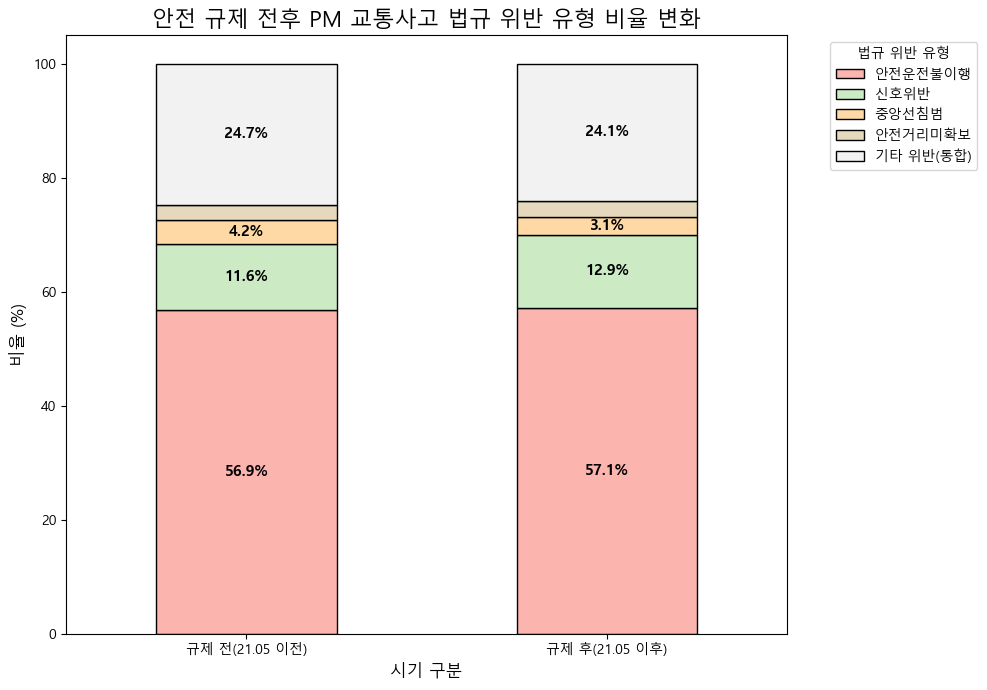

In [26]:
# 1. 시각화 대상 시기 필터링 (결측치 및 과도기 데이터 혼입 방지)
target_status = ['규제 전(21.05 이전)', '규제 후(21.05 이후)']
df_pie_target = df_incident[df_incident['규제여부'].isin(target_status)].copy()

# 2. '기타'를 제외한 순수 위반 항목 중에서 상위 3~4개만 추출
pure_violations = df_pie_target[df_pie_target['법규위반'] != '기타']['법규위반']
top_violations = pure_violations.value_counts().nlargest(4).index.tolist()

# 3. 새로운 그룹 컬럼 생성 ('기타' 항목과 나머지 하위 항목들을 모두 하나로 통합)
df_pie_target['법규위반_그룹'] = np.where(
    df_pie_target['법규위반'].isin(top_violations), 
    df_pie_target['법규위반'], 
    '기타 위반(통합)'
)

# 4. 교차표 생성 및 정렬
cross_tab = pd.crosstab(df_pie_target['규제여부'], df_pie_target['법규위반_그룹'])

# 열(위반 유형) 순서 정렬
ordered_cols = top_violations + ['기타 위반(통합)']
ordered_cols = [col for col in ordered_cols if col in cross_tab.columns]
cross_tab = cross_tab[ordered_cols]

# 행(시기) 순서 정렬
cross_tab = cross_tab.reindex(target_status)

# 5. 100% 비율(%)로 변환
cross_tab_prop = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

# 6. 100% 누적 막대 그래프 시각화
plt.figure(figsize=(10, 7))

ax = cross_tab_prop.plot(
    kind='bar', 
    stacked=True, 
    colormap='Pastel1', 
    edgecolor='black', 
    ax=plt.gca()
)

plt.title('안전 규제 전후 PM 교통사고 법규 위반 유형 비율 변화', fontsize=16)
plt.xlabel('시기 구분', fontsize=12)
plt.ylabel('비율 (%)', fontsize=12)
plt.xticks(rotation=0)

plt.legend(title='법규 위반 유형', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    
    if height > 3:
        ax.text(x + width / 2, 
                y + height / 2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center', 
                fontsize=11,
                fontweight='bold')

plt.tight_layout()
plt.show()

**그래프를 보면, 규제 전후로 법규 위반 유형의 근본적인 비율 구조는 거의 변하지 않았습니다.**

- 앞선 분석에서 "사고 건수는 늘었지만, 탑승자의 중대상해 비율은 18.9%에서 12.8%로 급감했다는 분석 내용이 있었습니다. 위 그래프는 그 이유를 뒷받침해줍니다.
- 사고가 발생하는 패턴(위반 유형)은 똑같은데 중대상해 비율만 떨어졌다는 것은, 헬멧 착용 의무화 같은 규제가 **'사고 자체를 예방(사전 방지)'하는 데는 실패했지만, '사고 발생 시 피해를 최소화(사후 보호)'하는 데는 확실한 효과를 거두었다**고 해석할 수 있습니다.

****

### **소결론**
- 다양한 시각화와 Bootstrapping을 통한 분석 결과, **PM 안전 규제 도입 이후 오히려 교통사고 건수는 통계적으로 유의미하게 크게 증가했습니다.**
  * 증가율 분포가 완전히 0(기준선)보다 훨씬 큰 양수 쪽에 위치하고 있으므로, 규제로 인한 사고 감소 효과는 확인되지 않았습니다. 이는 PM 시장의 팽창(이용량 급증)이라는 숨겨진 변수가 규제 효과를 압도했기 때문으로 추론할 수 있으며, 후속 가설(코로나 통제 변수 등)을 통해 이 점을 추가로 검증해야 합니다. **[가설검증 2, 3 참고]**



- 2021년 도로교통법 개정(헬멧 착용 의무화, 다인 탑승 금지 등)은 늘어나는 사고 자체를 막아내지는 못했지만, **사고가 발생했을 때 탑승자의 생명을 구하고 치명적인 부상을 감소시키는 성과가 있었습니다.**


- 안전 규제 전후 서울시 전체 PM 교통사고 주요 법규 위반 유형 비율은 규제 전과 규제 후의 큰 차이 없이 비슷한 양상을 띄고 있었습니다. 이는 **사고 자체를 예방하기보다는 사고 발생 시 치명률을 낮추는 데에는 확실한 효과를 거두었다**고 볼 수 있습니다.

****
****